# IC50 classification (> median)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     StratifiedKFold,)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, roc_auc_score,
                             classification_report, confusion_matrix)

In [ ]:
df = pd.read_csv('/content/df.csv')

In [ ]:
df.head()

,IC50,CC50,SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,IC50_log,CC50_log,SI_log
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


In [ ]:
logs= [col for col in df.columns if col.endswith('_log')]

df = df.drop(columns=logs, errors='ignore')

print(f"Удалено колонок: {len(logs)}")
print("Оставшиеся признаки:", df.shape[1])

Удалено колонок: 3
Оставшиеся признаки: 155


In [ ]:
df.shape

(969, 155)

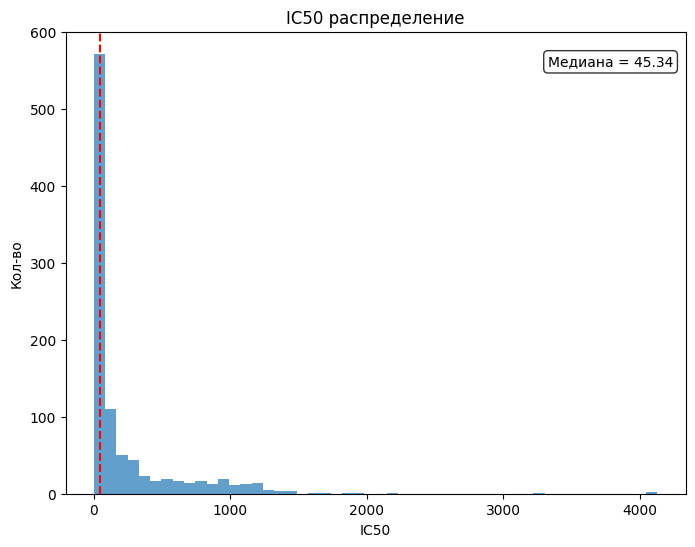

In [ ]:
median_IC50 = df['IC50'].median()

plt.figure(figsize=(8, 6))

plt.hist(df['IC50'], bins=50, alpha=0.7)
plt.axvline(median_IC50, color='red', linestyle='--')

plt.title('IC50 распределение')
plt.xlabel('IC50')
plt.ylabel('Кол-во')

# подпись в правом верхнем углу (box)
plt.gca().text(
    0.98, 0.95,
    f"Медиана = {median_IC50:.2f}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.show()

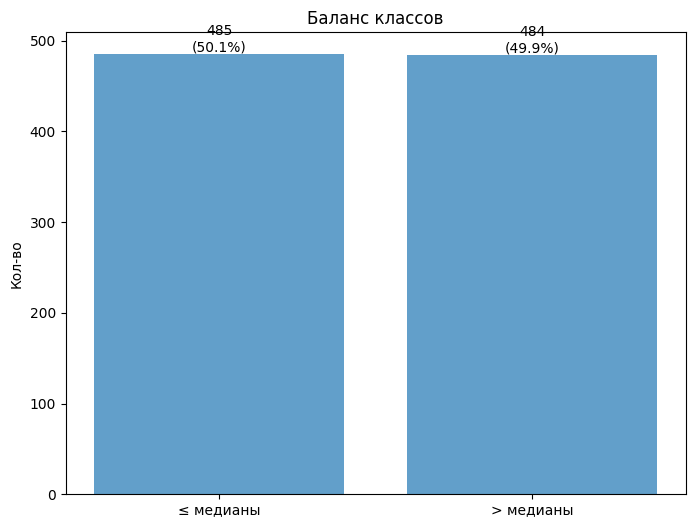

In [ ]:
df['IC50_above_median'] = (df['IC50'] > df['IC50'].median()).astype(int)

counts = df['IC50_above_median'].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure(figsize=(8, 6))

plt.bar(['≤ медианы', '> медианы'], counts.values, alpha=0.7)

plt.title('Баланс классов')
plt.ylabel('Кол-во')

for i, (c, p) in enumerate(zip(counts.values, percent.values)):
    plt.text(i, c, f'{c}\n({p:.1f}%)', ha='center', va='bottom')

plt.show()

,Model,ROC_AUC,F1,Accuracy,Precision,Recall
0,XGBoost,0.82,0.72,0.72,0.71,0.73
1,RandomForest,0.81,0.73,0.73,0.72,0.74
2,LogReg,0.77,0.71,0.71,0.72,0.70


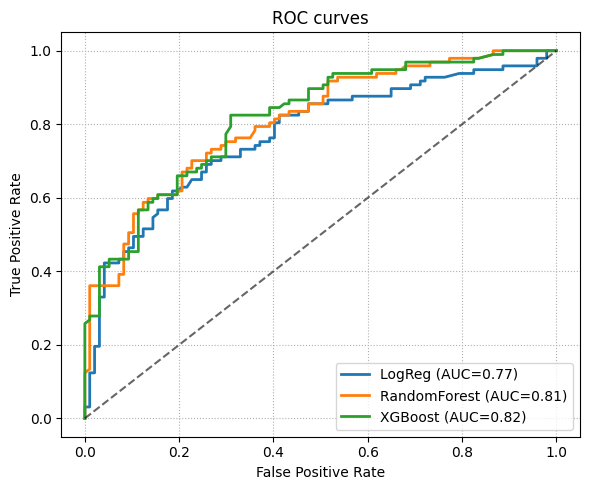

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y = df['IC50_above_median']
X = df.drop(columns=['IC50', 'CC50',
                     'SI', 'IC50_above_median'],
            errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

models = {
    'LogReg': (
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=3000, solver='liblinear'))]),
        {
            'model__C': [0.05, 0.1, 1, 5],
            'model__penalty': ['l1', 'l2'],
            'model__class_weight': [None, 'balanced']
        },
        'grid'),

    'RandomForest': (
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(random_state=42, n_jobs=-1))]),
        {
            'model__n_estimators': [250, 400],
            'model__max_depth': [None, 16],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2],
            'model__class_weight': [None, 'balanced']
        },
        'random'),

    'XGBoost': (
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('model', XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                n_jobs=-1))]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample': [0.7, 0.85],
            'model__colsample_bytree': [0.7, 1.0]
        },
        'random')}

results = []
best_models = {}

for name, (pipe, params, kind) in models.items():

    search = (
        GridSearchCV(pipe, params, cv=cv, scoring='roc_auc', n_jobs=-1)
        if kind == 'grid'
        else RandomizedSearchCV(
            pipe,
            params,
            n_iter=10,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1,
            random_state=42))

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_score = best_model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'ROC_AUC': float(roc_auc_score(y_test, y_score)),
        'F1': float(f1_score(y_test, y_pred)),
        'Accuracy': float(accuracy_score(y_test, y_pred)),
        'Precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_test, y_pred, zero_division=0))})

    best_models[name] = best_model

df_res = (
    pd.DataFrame(results)
    .sort_values('ROC_AUC', ascending=False)
    .reset_index(drop=True))

df_res = df_res.round(2)
display(df_res)
plt.figure(figsize=(6, 5))

for name, model in best_models.items():

    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

## Интерпретация результатов моделей
- RandomForest показал хорошие результаты ROC-AUC(0.81) и лидирует по метрикам Accuracy(0.73) и Recall(0.74), что важно для минимизации ложноотрицательных срабатываний.